In [1]:
!pip install pandas numpy matplotlib seaborn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✅ Libraries loaded.")

✅ Libraries loaded.


In [4]:
# ── CELL 2: Load Dataset ─────────────────────────────────────
import pandas as pd

df = pd.read_csv('/Merged_Nexus_Dataset.csv')

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n📋 Column Names:")
print(df.columns.tolist())

✅ Dataset loaded: 1403819 rows × 56 columns

📋 Column Names:
['slno', 'node_id', 'gwid', 'dtcname', 'tccode', 'meterno', 'realtimeclock', 'cumulativeenergykwhimport', 'phasecurrent', 'neutralcurrent', 'voltage', 'currentrphase', 'currentyphase', 'currentbphase', 'voltagerphase', 'voltageyphase', 'voltagebphase', 'pfrphase', 'pfyphase', 'pfbphase', 'avgpf', 'frequency', 'cumulativeenergykvahimport', 'cumulativeenergykvahexport', 'apparentpowerkva', 'signedactivepowerkw', 'signedreactivepowerkvar', 'noofpowerfailures', 'cumulativepoweroffdurationinmin', 'cumulativepowerondurationinmin', 'cummulativetampercount', 'cummulativebillingcount', 'cummulativeprogrammingcount', 'billingdate', 'cumulativeenergykwhexport', 'maximumdemandkw', 'maximumdemandkva', 'loadlimitfunctionstatus', 'loadlimitvaluekw', 'cumulativeenergykvarh_q1', 'cumulativeenergykvarh_q2', 'cumulativeenergykvarh_q3', 'cumulativeenergykvarh_q4', 'captured_date_time', 'uniqueid_x', 'phase', 'signalstrength', 'issid', 'time_key'

In [5]:
# ── CELL 3: Preprocessing ────────────────────────────────────
# Parse timestamps
timestamp_col = 'timestamp'   # change if your column name differs
flowrate_col  = 'flowrate'
water_col     = 'water_data'
current_cols  = ['currentrphase', 'currentyphase', 'currentbphase']
pump_id_col   = 'rr_no'       # or 'uniqueid' — pump identifier

df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
df = df.dropna(subset=[timestamp_col])
df = df.sort_values(timestamp_col).reset_index(drop=True)

# Extract time features
df['hour']       = df[timestamp_col].dt.hour
df['date']       = df[timestamp_col].dt.date
df['day_of_week']= df[timestamp_col].dt.day_name()

# Numeric coercion
for col in [flowrate_col, water_col] + current_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Average current across 3 phases
df['avg_current'] = df[[c for c in current_cols if c in df.columns]].mean(axis=1)

print("✅ Preprocessing done.")
print(df[[timestamp_col, flowrate_col, 'avg_current', 'hour']].head(10))


✅ Preprocessing done.
            timestamp  flowrate  avg_current  hour
0 2025-09-18 00:00:01     2.678     0.000000     0
1 2025-09-18 00:00:01     2.678     0.000000     0
2 2025-10-05 08:00:01     0.000     0.004500     8
3 2025-11-12 14:00:01     2.311    20.625467    14
4 2025-11-18 17:50:24     0.000     0.000000    17
5 2025-11-21 07:58:42     0.000    32.180467     7
6 2025-12-04 15:20:08     0.000     0.000000    15
7 2025-12-05 11:30:27     0.000     0.000000    11
8 2025-12-09 07:00:01     0.000     0.000000     7
9 2025-12-12 07:00:02     0.000    31.279300     7



ANALYSIS 1: NIGHTTIME FLOW ANOMALY DETECTION (11PM–5AM)

🌙 Nighttime records with non-zero flow: 60196
   This is 4.29% of total dataset

   Overall mean flow       : 3.058
   Leak detection threshold: 0.153

🚨 Nighttime Anomalies:
               timestamp  flowrate  hour                    anomaly_type
0    2025-09-18 00:00:01     2.678     0  CRITICAL — Possible Pipe Burst
1    2025-09-18 00:00:01     2.678     0  CRITICAL — Possible Pipe Burst
9463 2025-12-25 23:00:01    17.583    23  CRITICAL — Possible Pipe Burst
9473 2025-12-25 23:00:01     0.243    23  WARNING — Tank Overflow Likely
9475 2025-12-25 23:00:01     3.809    23  CRITICAL — Possible Pipe Burst
9476 2025-12-25 23:00:01     0.178    23  WARNING — Tank Overflow Likely
9494 2025-12-25 23:00:01    11.984    23  CRITICAL — Possible Pipe Burst
9497 2025-12-25 23:00:01    14.006    23  CRITICAL — Possible Pipe Burst
9511 2025-12-25 23:00:01     0.633    23  WARNING — Tank Overflow Likely
9532 2025-12-25 23:00:01    13.699   

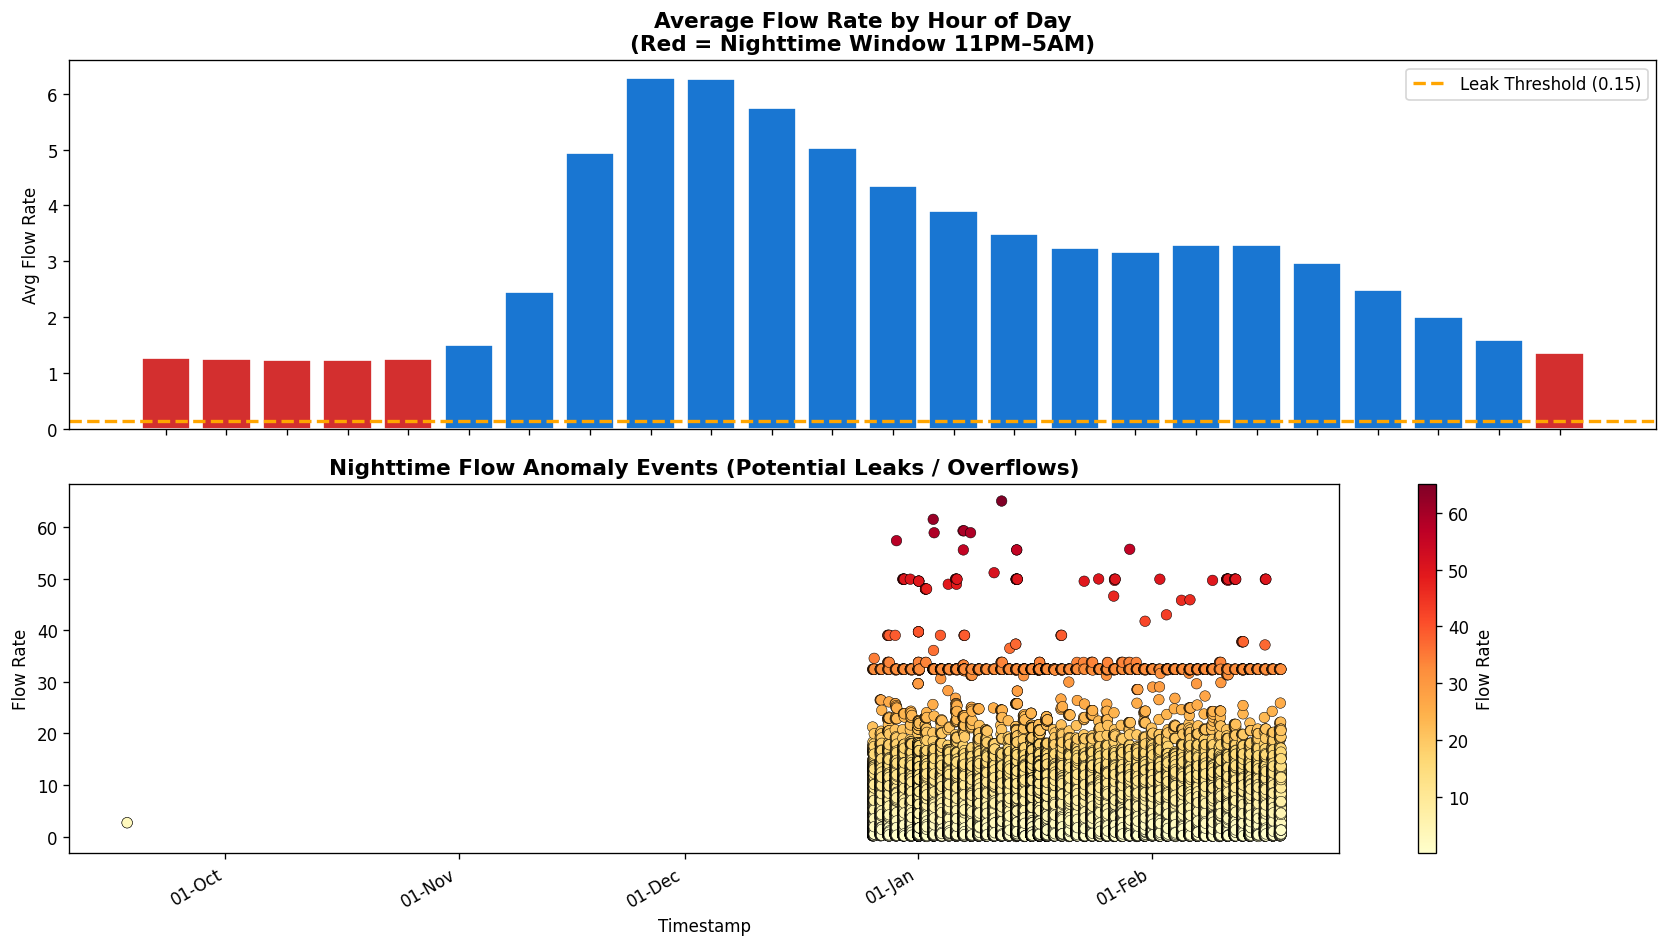

✅ Plot saved: nighttime_leak_detection.png


In [7]:
# ── CELL 4: ANALYSIS 1 — Nighttime Flow Leak Detection ───────
print("\n" + "="*60)
print("ANALYSIS 1: NIGHTTIME FLOW ANOMALY DETECTION (11PM–5AM)")
print("="*60)

NIGHT_START = 23
NIGHT_END   = 5

night_mask = (df['hour'] >= NIGHT_START) | (df['hour'] < NIGHT_END)
night_flow = df[night_mask & (df[flowrate_col] > 0)].copy()

print(f"\n🌙 Nighttime records with non-zero flow: {len(night_flow)}")
print(f"   This is {len(night_flow)/len(df)*100:.2f}% of total dataset")

# Fix: use overall mean instead of daytime median (daytime median was 0)
overall_mean_flow = df[flowrate_col].mean()
LEAK_THRESHOLD = overall_mean_flow * 0.05

night_flow['anomaly_type'] = np.where(
    night_flow[flowrate_col] > overall_mean_flow * 0.5,
    'CRITICAL — Possible Pipe Burst',
    'WARNING — Tank Overflow Likely'
)

print(f"\n   Overall mean flow       : {overall_mean_flow:.3f}")
print(f"   Leak detection threshold: {LEAK_THRESHOLD:.3f}")
print(f"\n🚨 Nighttime Anomalies:")
print(night_flow[[timestamp_col, flowrate_col, 'hour', 'anomaly_type']].head(20))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

hourly_avg = df.groupby('hour')[flowrate_col].mean().reset_index()
colors = ['#d32f2f' if (h >= NIGHT_START or h < NIGHT_END) else '#1976d2'
          for h in hourly_avg['hour']]
axes[0].bar(hourly_avg['hour'], hourly_avg[flowrate_col], color=colors, edgecolor='white')
axes[0].axhline(LEAK_THRESHOLD, color='orange', linestyle='--', linewidth=2,
                label=f'Leak Threshold ({LEAK_THRESHOLD:.2f})')
axes[0].set_title('Average Flow Rate by Hour of Day\n(Red = Nighttime Window 11PM–5AM)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Flow Rate')
axes[0].legend()
axes[0].set_xticks(range(24))

# Fix: changed cmap from 'RdYlOr' to 'YlOrRd' (valid matplotlib cmap)
if not night_flow.empty:
    sc = axes[1].scatter(night_flow[timestamp_col], night_flow[flowrate_col],
                         c=night_flow[flowrate_col], cmap='YlOrRd', s=40,
                         edgecolors='k', linewidths=0.3)
    plt.colorbar(sc, ax=axes[1], label='Flow Rate')
    axes[1].set_title('Nighttime Flow Anomaly Events (Potential Leaks / Overflows)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Timestamp')
    axes[1].set_ylabel('Flow Rate')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('nighttime_leak_detection.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: nighttime_leak_detection.png")


ANALYSIS 2: IMPELLER WEAR DETECTION
Current ↑ + Flow ↓  =>  Mechanical Degradation

🔧 Days with Impeller Wear Signature (Flow ↓>15% + Current ↑): 3
      date  daily_flow  daily_current  flow_drop_pct
2025-11-21         0.0      32.180467          100.0
2025-12-12         0.0      31.279300          100.0
2025-12-24         0.0      16.032680          100.0


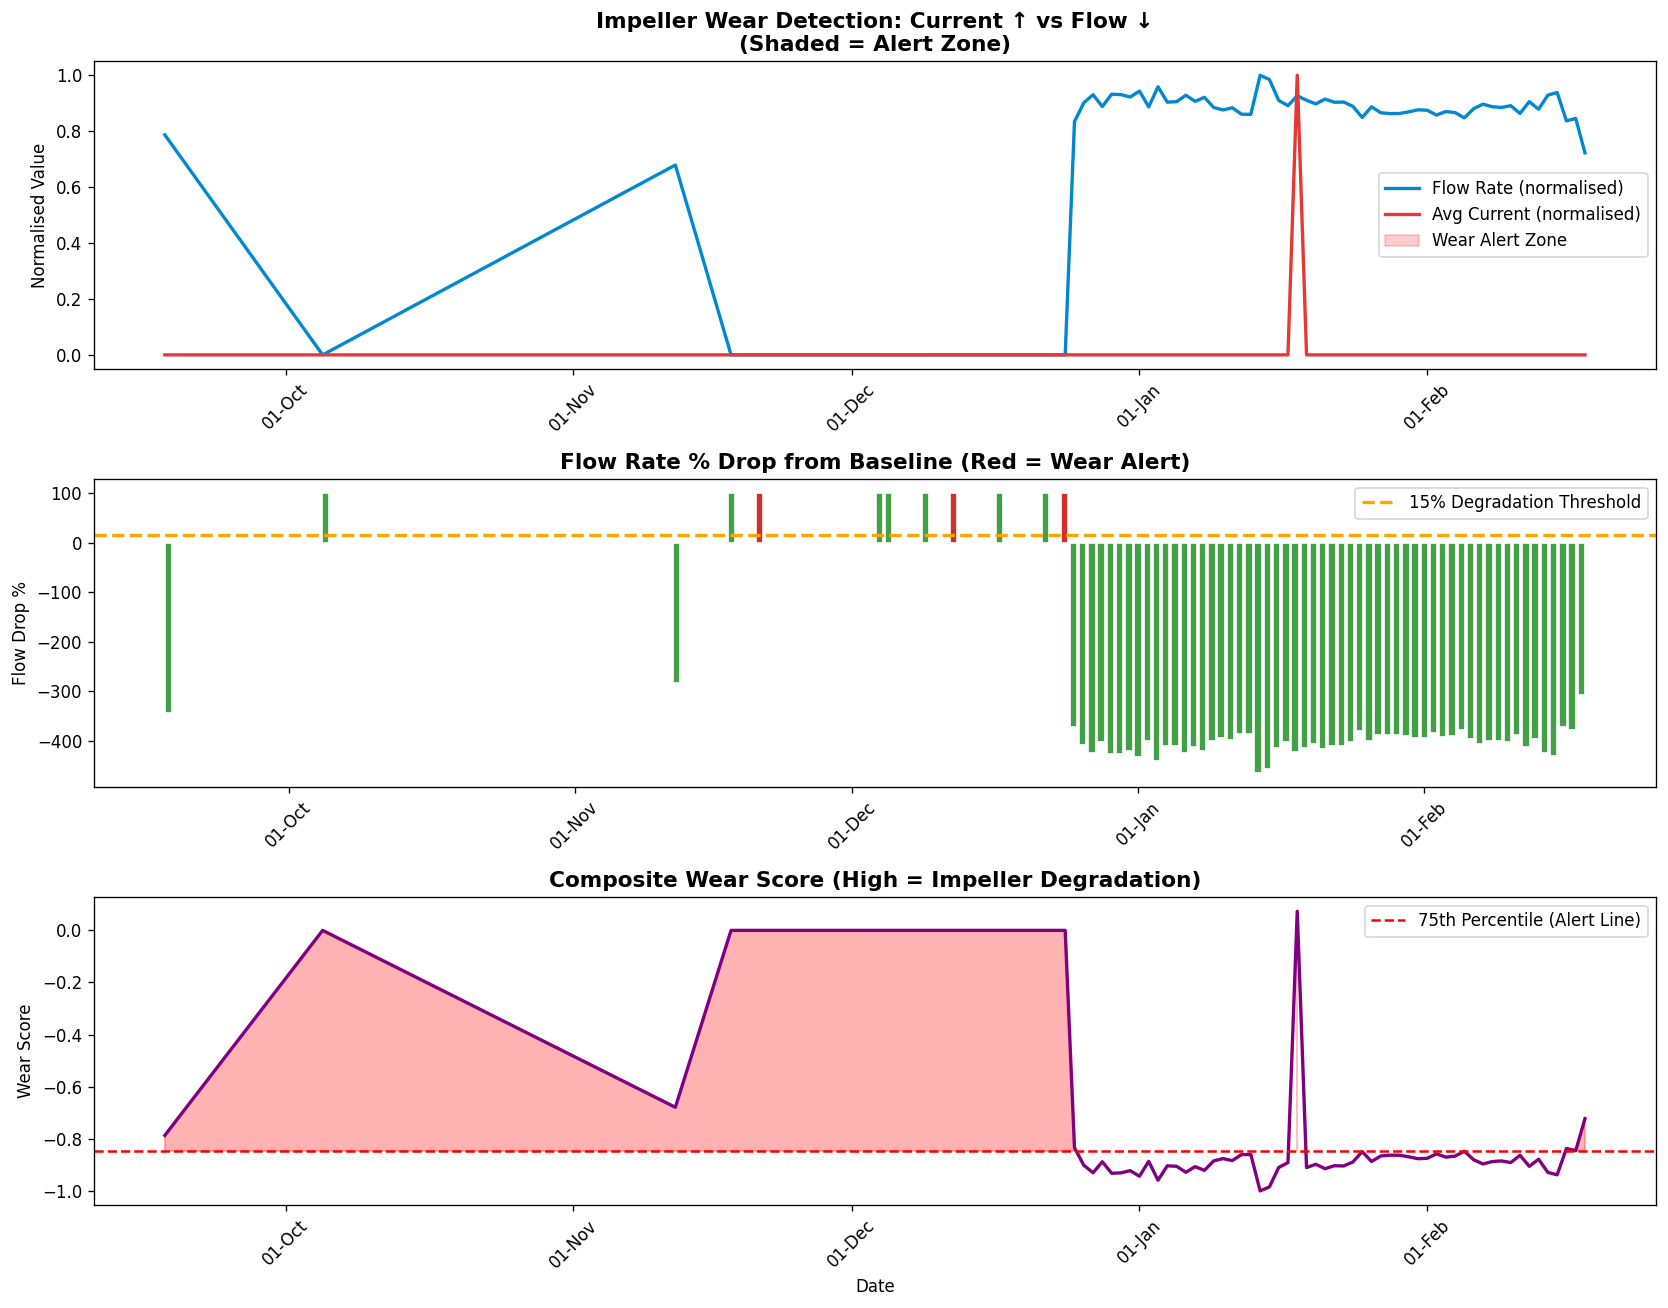

✅ Plot saved: impeller_wear_detection.png


In [8]:
# ── CELL 5: ANALYSIS 2 — Impeller Wear Detection ─────────────
# Worn impeller signature: current RISES while flow DROPS
# Mechanical degradation → pump works harder, delivers less water

print("\n" + "="*60)
print("ANALYSIS 2: IMPELLER WEAR DETECTION")
print("Current ↑ + Flow ↓  =>  Mechanical Degradation")
print("="*60)

# Rolling 7-day window to smooth noise
df_sorted = df.sort_values(timestamp_col).copy()
df_sorted = df_sorted.set_index(timestamp_col)

daily = df_sorted[[flowrate_col, 'avg_current']].resample('D').mean().dropna()
daily = daily.reset_index()
daily.columns = ['date', 'daily_flow', 'daily_current']

# Normalize 0-1 for comparison
daily['flow_norm']    = (daily['daily_flow']    - daily['daily_flow'].min())    / (daily['daily_flow'].max()    - daily['daily_flow'].min() + 1e-9)
daily['current_norm'] = (daily['daily_current'] - daily['daily_current'].min()) / (daily['daily_current'].max() - daily['daily_current'].min() + 1e-9)

# Wear Score: high current + low flow = high wear
daily['wear_score'] = daily['current_norm'] - daily['flow_norm']
daily['wear_flag']  = daily['wear_score'] > daily['wear_score'].quantile(0.75)

# Baseline: first 20% of timeline
baseline_end = int(len(daily) * 0.2)
baseline_flow = daily['daily_flow'].iloc[:baseline_end].mean()

daily['flow_drop_pct'] = (baseline_flow - daily['daily_flow']) / (baseline_flow + 1e-9) * 100
daily['wear_alert'] = (daily['flow_drop_pct'] > 15) & (daily['daily_current'] > daily['daily_current'].median())

wear_days = daily[daily['wear_alert']]
print(f"\n🔧 Days with Impeller Wear Signature (Flow ↓>15% + Current ↑): {len(wear_days)}")
print(wear_days[['date', 'daily_flow', 'daily_current', 'flow_drop_pct']].to_string(index=False))

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

axes[0].plot(daily['date'], daily['flow_norm'], color='#0288d1', linewidth=2, label='Flow Rate (normalised)')
axes[0].plot(daily['date'], daily['current_norm'], color='#e53935', linewidth=2, label='Avg Current (normalised)')
axes[0].fill_between(daily['date'], daily['flow_norm'], daily['current_norm'],
                     where=daily['wear_alert'], alpha=0.2, color='red', label='Wear Alert Zone')
axes[0].set_title('Impeller Wear Detection: Current ↑ vs Flow ↓\n(Shaded = Alert Zone)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Normalised Value')
axes[0].legend()

axes[1].bar(daily['date'], daily['flow_drop_pct'],
            color=['#d32f2f' if x else '#43a047' for x in daily['wear_alert']],
            edgecolor='white')
axes[1].axhline(15, color='orange', linestyle='--', linewidth=2, label='15% Degradation Threshold')
axes[1].set_title('Flow Rate % Drop from Baseline (Red = Wear Alert)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Flow Drop %')
axes[1].legend()

axes[2].plot(daily['date'], daily['wear_score'], color='purple', linewidth=2)
axes[2].axhline(daily['wear_score'].quantile(0.75), color='red', linestyle='--',
                label='75th Percentile (Alert Line)')
axes[2].fill_between(daily['date'], daily['wear_score'],
                     daily['wear_score'].quantile(0.75),
                     where=daily['wear_score'] > daily['wear_score'].quantile(0.75),
                     alpha=0.3, color='red')
axes[2].set_title('Composite Wear Score (High = Impeller Degradation)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Wear Score')
axes[2].set_xlabel('Date')
axes[2].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('impeller_wear_detection.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: impeller_wear_detection.png")




ANALYSIS 3: BASELINE FLOW VARIANCE & ANOMALY FLAGGING

📊 Flow Statistics:
   Mean flow rate  : 3.0584
   Std deviation   : 5.4028
   Q1 / Q3         : 0.0000 / 4.8950
   IQR             : 4.8950

🚨 Total anomalies flagged: 139914 (9.97% of data)


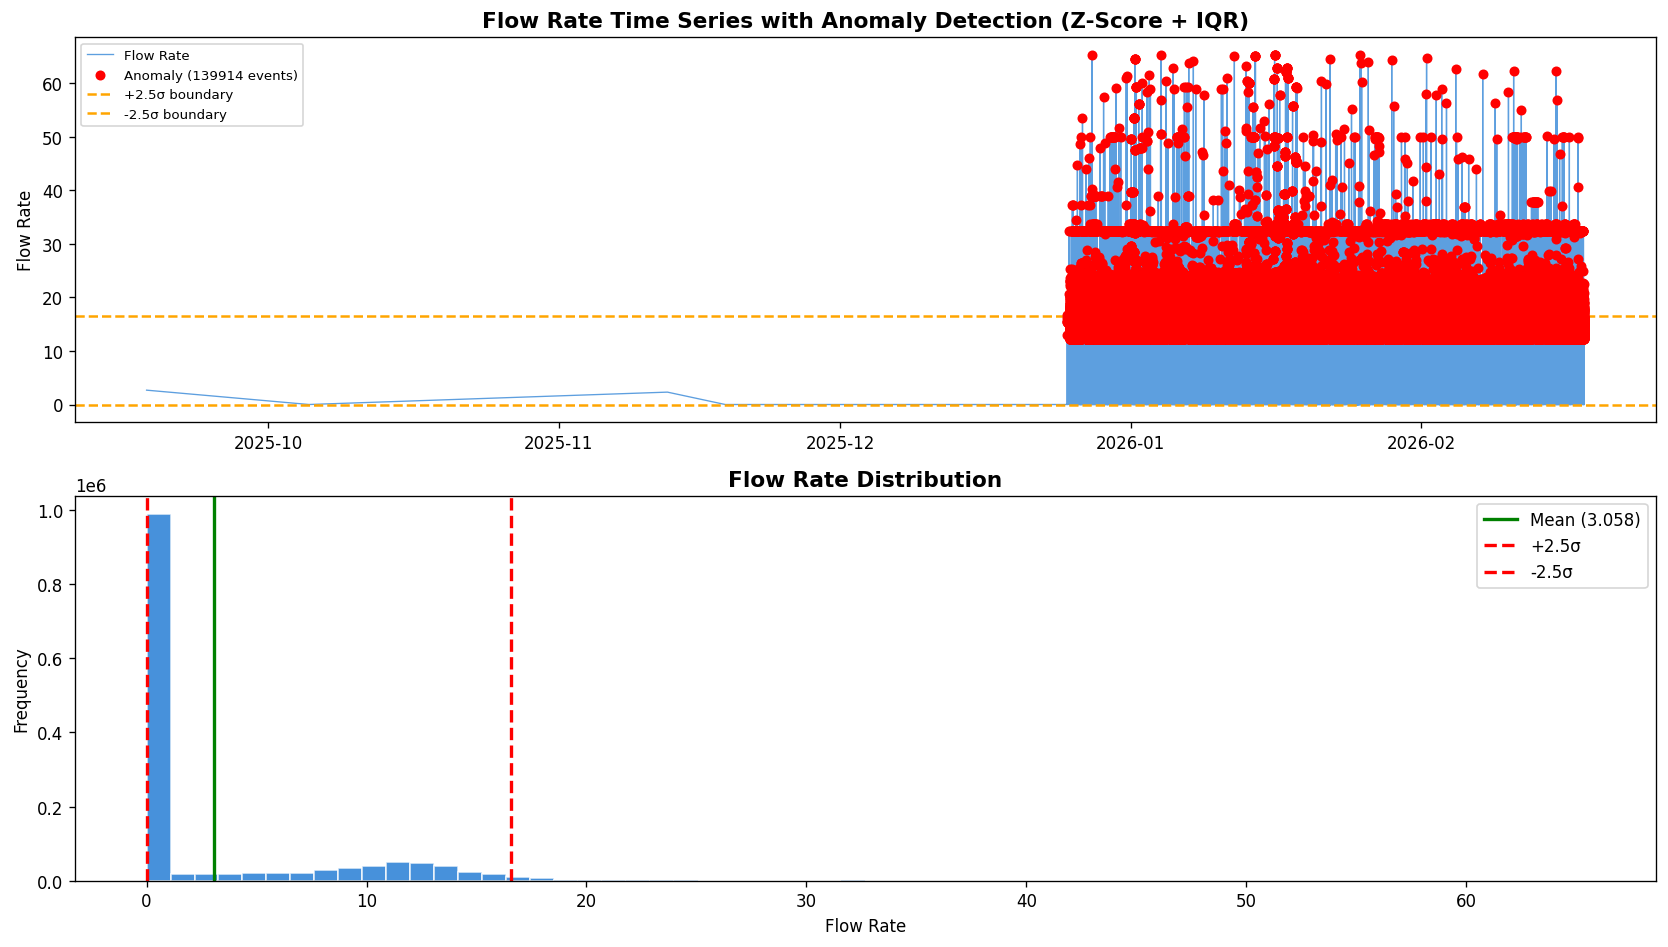

✅ Plot saved: flow_variance_anomaly.png


In [9]:
# ── CELL 6: ANALYSIS 3 — Baseline Flow Variance & Z-Score Flagging ──
print("\n" + "="*60)
print("ANALYSIS 3: BASELINE FLOW VARIANCE & ANOMALY FLAGGING")
print("="*60)

# Z-score method: flag anything beyond ±2.5 std as anomaly
flow_mean = df[flowrate_col].mean()
flow_std  = df[flowrate_col].std()

df['flow_zscore'] = (df[flowrate_col] - flow_mean) / (flow_std + 1e-9)
df['flow_anomaly_zscore'] = df['flow_zscore'].abs() > 2.5

# IQR method (second layer)
Q1 = df[flowrate_col].quantile(0.25)
Q3 = df[flowrate_col].quantile(0.75)
IQR = Q3 - Q1
df['flow_anomaly_iqr'] = (df[flowrate_col] < Q1 - 1.5*IQR) | (df[flowrate_col] > Q3 + 1.5*IQR)

# Combined flag
df['flow_anomaly'] = df['flow_anomaly_zscore'] | df['flow_anomaly_iqr']

n_anomalies = df['flow_anomaly'].sum()
print(f"\n📊 Flow Statistics:")
print(f"   Mean flow rate  : {flow_mean:.4f}")
print(f"   Std deviation   : {flow_std:.4f}")
print(f"   Q1 / Q3         : {Q1:.4f} / {Q3:.4f}")
print(f"   IQR             : {IQR:.4f}")
print(f"\n🚨 Total anomalies flagged: {n_anomalies} ({n_anomalies/len(df)*100:.2f}% of data)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series with anomalies
axes[0].plot(df[timestamp_col], df[flowrate_col], color='#1976d2', linewidth=0.8, alpha=0.7, label='Flow Rate')
anomaly_df = df[df['flow_anomaly']]
axes[0].scatter(anomaly_df[timestamp_col], anomaly_df[flowrate_col],
                color='red', s=25, zorder=5, label=f'Anomaly ({n_anomalies} events)')
axes[0].axhline(flow_mean + 2.5*flow_std, color='orange', linestyle='--', linewidth=1.5, label='+2.5σ boundary')
axes[0].axhline(max(0, flow_mean - 2.5*flow_std), color='orange', linestyle='--', linewidth=1.5, label='-2.5σ boundary')
axes[0].set_title('Flow Rate Time Series with Anomaly Detection (Z-Score + IQR)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Flow Rate')
axes[0].legend(fontsize=8)

# Distribution
axes[1].hist(df[flowrate_col].dropna(), bins=60, color='#1976d2', edgecolor='white', alpha=0.8)
axes[1].axvline(flow_mean, color='green', linewidth=2, label=f'Mean ({flow_mean:.3f})')
axes[1].axvline(flow_mean + 2.5*flow_std, color='red', linestyle='--', linewidth=2, label='+2.5σ')
axes[1].axvline(max(0, flow_mean - 2.5*flow_std), color='red', linestyle='--', linewidth=2, label='-2.5σ')
axes[1].set_title('Flow Rate Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Flow Rate')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('flow_variance_anomaly.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: flow_variance_anomaly.png")


ANALYSIS 4: CURRENT vs FLOW CORRELATION
Healthy pump: strong positive correlation
Worn pump: correlation degrades over time

📈 Pearson Correlation (Current vs Flow): r = -0.0010, p = 2.5763e-01
   Pump Health Status: CRITICAL — Weak/negative correlation, impeller likely worn


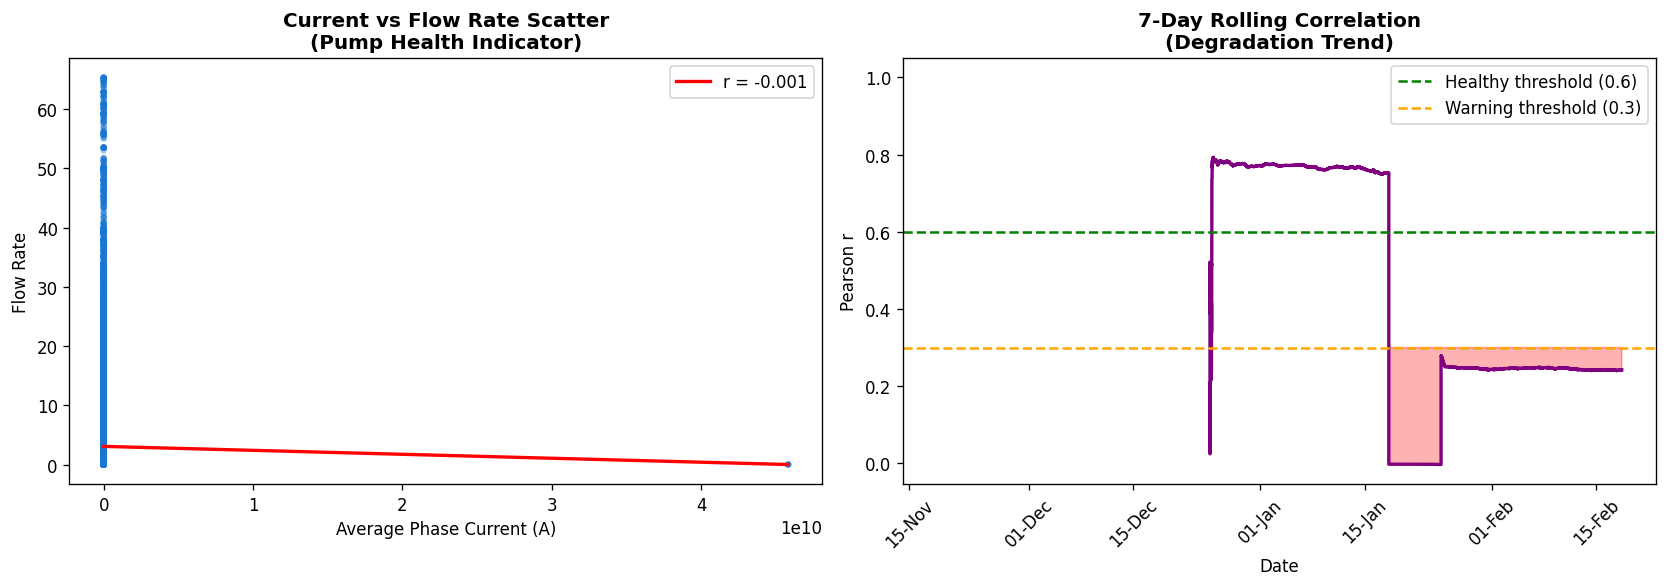

✅ Plot saved: current_flow_correlation.png


In [10]:
# ── CELL 7: ANALYSIS 4 — Current vs Flow Correlation (Pump Health) ──
print("\n" + "="*60)
print("ANALYSIS 4: CURRENT vs FLOW CORRELATION")
print("Healthy pump: strong positive correlation")
print("Worn pump: correlation degrades over time")
print("="*60)

valid = df[[flowrate_col, 'avg_current']].dropna()
corr, pval = stats.pearsonr(valid['avg_current'], valid[flowrate_col])
print(f"\n📈 Pearson Correlation (Current vs Flow): r = {corr:.4f}, p = {pval:.4e}")

if corr > 0.6:
    health = "HEALTHY — Strong positive correlation"
elif corr > 0.3:
    health = "DEGRADING — Moderate correlation, monitor closely"
else:
    health = "CRITICAL — Weak/negative correlation, impeller likely worn"
print(f"   Pump Health Status: {health}")

# Rolling 7-day correlation to show degradation over time
df_temp = df[[timestamp_col, flowrate_col, 'avg_current']].dropna().set_index(timestamp_col)
rolling_corr = df_temp[flowrate_col].rolling('7D').corr(df_temp['avg_current']).reset_index()
rolling_corr.columns = ['timestamp', 'rolling_corr']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valid['avg_current'], valid[flowrate_col],
                alpha=0.4, color='#1976d2', s=15, edgecolors='none')
m, b = np.polyfit(valid['avg_current'], valid[flowrate_col], 1)
x_line = np.linspace(valid['avg_current'].min(), valid['avg_current'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'r = {corr:.3f}')
axes[0].set_title('Current vs Flow Rate Scatter\n(Pump Health Indicator)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Phase Current (A)')
axes[0].set_ylabel('Flow Rate')
axes[0].legend()

axes[1].plot(rolling_corr['timestamp'], rolling_corr['rolling_corr'],
             color='purple', linewidth=2)
axes[1].axhline(0.6, color='green', linestyle='--', linewidth=1.5, label='Healthy threshold (0.6)')
axes[1].axhline(0.3, color='orange', linestyle='--', linewidth=1.5, label='Warning threshold (0.3)')
axes[1].fill_between(rolling_corr['timestamp'], rolling_corr['rolling_corr'], 0.3,
                     where=rolling_corr['rolling_corr'] < 0.3, alpha=0.3, color='red')
axes[1].set_title('7-Day Rolling Correlation\n(Degradation Trend)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pearson r')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('current_flow_correlation.png', bbox_inches='tight')
plt.show()
print("✅ Plot saved: current_flow_correlation.png")


ANALYSIS 5: PER-PUMP HEALTH SUMMARY

📊 Per-Pump Summary:
                 rr_no  total_records  avg_flow  std_flow  avg_current  flow_anomalies  max_flow  min_flow   cv_flow  anomaly_pct health_status
               1NGP109            980  0.976829  2.180176 4.294621e+00               0    10.171     0.000  2.231892     0.000000    🔴 CRITICAL
               1NGP112           1524  0.482729  3.039129 1.557819e+00              23    32.428     0.000  6.295725     1.509186    🔴 CRITICAL
               1NGP123           1578  2.693289  3.850747 1.259477e+01               2    20.961     0.000  1.429756     0.126743    🔴 CRITICAL
               1NGP126            200  8.151405  5.000345 2.535309e+01              17    13.307     0.000  0.613434     8.500000    🔴 CRITICAL
               1NGP175            203  2.176744  4.296909 8.339307e+00               3    17.817     0.000  1.974008     1.477833    🔴 CRITICAL
               1NGP177            156  5.022660  0.462111 3.470558e+01        

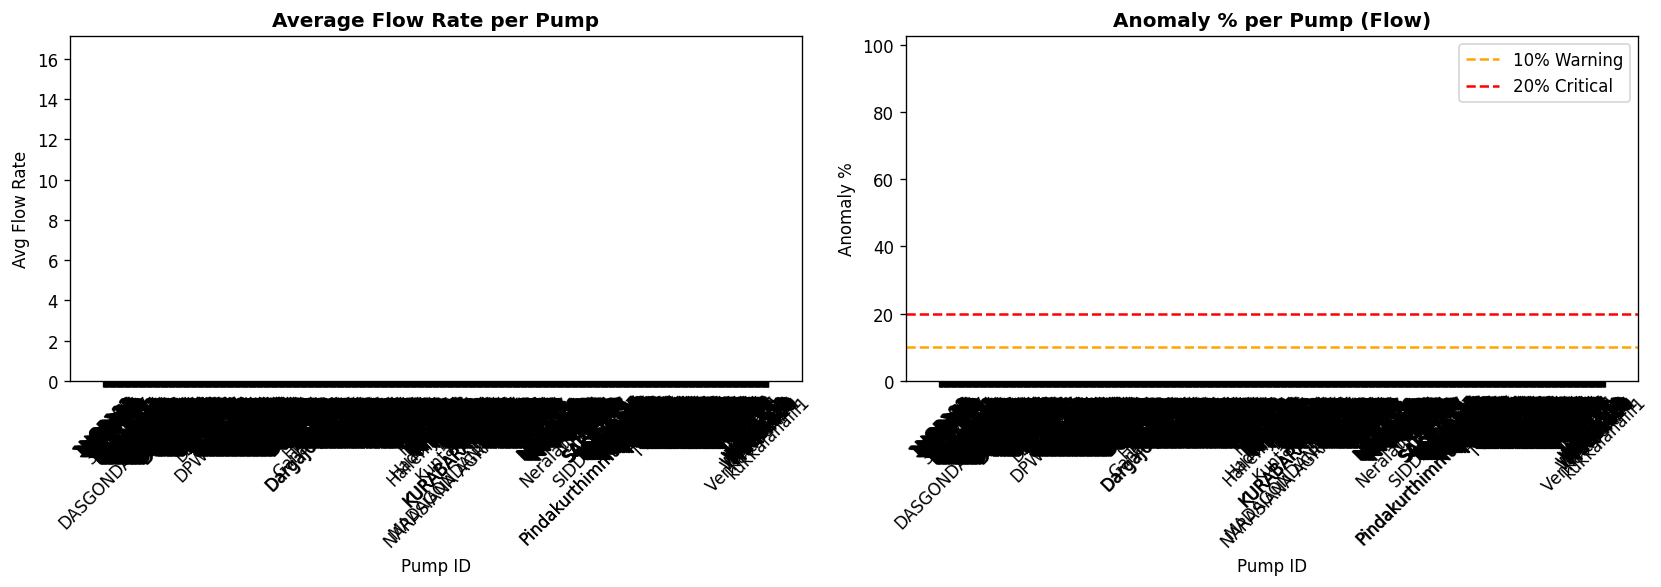

✅ Plot saved: per_pump_health.png


In [11]:
# ── CELL 8: ANALYSIS 5 — Per-Pump Summary (if multiple pumps) ──
print("\n" + "="*60)
print("ANALYSIS 5: PER-PUMP HEALTH SUMMARY")
print("="*60)

if pump_id_col in df.columns:
    pump_summary = df.groupby(pump_id_col).agg(
        total_records   = (flowrate_col, 'count'),
        avg_flow        = (flowrate_col, 'mean'),
        std_flow        = (flowrate_col, 'std'),
        avg_current     = ('avg_current', 'mean'),
        flow_anomalies  = ('flow_anomaly', 'sum'),
        max_flow        = (flowrate_col, 'max'),
        min_flow        = (flowrate_col, 'min'),
    ).reset_index()

    pump_summary['cv_flow'] = pump_summary['std_flow'] / (pump_summary['avg_flow'] + 1e-9)  # coefficient of variation
    pump_summary['anomaly_pct'] = pump_summary['flow_anomalies'] / pump_summary['total_records'] * 100

    # Health rating
    def health_rating(row):
        if row['anomaly_pct'] > 20 or row['cv_flow'] > 0.5:
            return '🔴 CRITICAL'
        elif row['anomaly_pct'] > 10 or row['cv_flow'] > 0.3:
            return '🟡 WARNING'
        else:
            return '🟢 HEALTHY'

    pump_summary['health_status'] = pump_summary.apply(health_rating, axis=1)
    print("\n📊 Per-Pump Summary:")
    print(pump_summary.to_string(index=False))

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#d32f2f' if '🔴' in s else '#fbc02d' if '🟡' in s else '#388e3c'
              for s in pump_summary['health_status']]

    axes[0].bar(pump_summary[pump_id_col].astype(str), pump_summary['avg_flow'],
                color=colors, edgecolor='white')
    axes[0].set_title('Average Flow Rate per Pump', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Pump ID')
    axes[0].set_ylabel('Avg Flow Rate')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(pump_summary[pump_id_col].astype(str), pump_summary['anomaly_pct'],
                color=colors, edgecolor='white')
    axes[1].axhline(10, color='orange', linestyle='--', label='10% Warning')
    axes[1].axhline(20, color='red',    linestyle='--', label='20% Critical')
    axes[1].set_title('Anomaly % per Pump (Flow)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Pump ID')
    axes[1].set_ylabel('Anomaly %')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('per_pump_health.png', bbox_inches='tight')
    plt.show()
    print("✅ Plot saved: per_pump_health.png")

In [15]:
# ── CELL 9: Export Output CSVs for Dashboard Lead ────────────
from google.colab import files

print("\n" + "="*60)
print("EXPORTING OUTPUT CSVs FOR DASHBOARD (Policy Lead)")
print("="*60)

# --- Flow_Anomalies.csv ---
flow_anomaly_export = df[df['flow_anomaly']][[
    timestamp_col,
    pump_id_col if pump_id_col in df.columns else 'slno',
    flowrate_col, 'flow_zscore', 'hour'
]].copy()
flow_anomaly_export['anomaly_type'] = np.where(
    (flow_anomaly_export['hour'] >= 23) | (flow_anomaly_export['hour'] < 5),
    'NIGHTTIME LEAK', 'DAYTIME SPIKE'
)
flow_anomaly_export.to_csv('Flow_Anomalies.csv', index=False)
print(f"✅ Flow_Anomalies.csv saved — {len(flow_anomaly_export)} anomaly records")

# --- Wear_Alerts.csv ---
wear_export = daily[daily['wear_alert']][[
    'date', 'daily_flow', 'daily_current', 'flow_drop_pct', 'wear_score'
]].copy()
wear_export['alert_type'] = 'IMPELLER_WEAR'
wear_export.to_csv('Wear_Alerts.csv', index=False)
print(f"✅ Wear_Alerts.csv saved — {len(wear_export)} wear alert days")

# --- Nighttime_Leaks.csv ---
if not night_flow.empty:
    night_flow[[timestamp_col, flowrate_col, 'hour', 'anomaly_type']].to_csv(
        'Nighttime_Leaks.csv', index=False)
    print(f"✅ Nighttime_Leaks.csv saved — {len(night_flow)} leak events")

# --- NRW_Daily.csv (Non-Revenue Water) ---
if water_col in df.columns:
    df['NRW_estimate'] = df[flowrate_col] - df[water_col]
    nrw_daily = df.groupby('date')['NRW_estimate'].sum().reset_index()
    nrw_daily.columns = ['date', 'NRW_litres_lost']
    nrw_daily['NRW_status'] = np.where(
        nrw_daily['NRW_litres_lost'] > nrw_daily['NRW_litres_lost'].quantile(0.75),
        'HIGH LOSS', 'NORMAL'
    )
    nrw_daily.to_csv('NRW_Daily.csv', index=False)
    print(f"✅ NRW_Daily.csv saved — {len(nrw_daily)} days of NRW data")
    print(f"   Avg daily NRW loss : {nrw_daily['NRW_litres_lost'].mean():.3f}")
    print(f"   Max daily NRW loss : {nrw_daily['NRW_litres_lost'].max():.3f}")
else:
    print("⚠️  water_col not found — skipping NRW calculation")

# Download all files
files.download('Flow_Anomalies.csv')
files.download('Wear_Alerts.csv')
if not night_flow.empty:
    files.download('Nighttime_Leaks.csv')
if water_col in df.columns:
    files.download('NRW_Daily.csv')

print("\n✅ ALL EXPORTS COMPLETE. Hand these CSVs to the Policy Lead.")


EXPORTING OUTPUT CSVs FOR DASHBOARD (Policy Lead)
✅ Flow_Anomalies.csv saved — 139914 anomaly records
✅ Wear_Alerts.csv saved — 3 wear alert days
✅ Nighttime_Leaks.csv saved — 60196 leak events
✅ NRW_Daily.csv saved — 68 days of NRW data
   Avg daily NRW loss : -68788535055.670
   Max daily NRW loss : -10486.000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL EXPORTS COMPLETE. Hand these CSVs to the Policy Lead.


In [14]:
# ── CELL 10: Summary Report for Paper ────────────────────────
print("\n" + "="*60)
print("ROLE 3 PAPER SUMMARY — KEY FINDINGS")
print("="*60)

print(f"""
┌─────────────────────────────────────────────────────────┐
│            HYDROLOGICAL & INFRASTRUCTURE AUDIT          │
├─────────────────────────────────────────────────────────┤
│ Total Records Analysed    : {len(df):>10,}               │
│ Date Range                : {str(df[timestamp_col].min().date())} → {str(df[timestamp_col].max().date())}  │
├─────────────────────────────────────────────────────────┤
│ LEAK DETECTION (Nighttime Flow Anomalies)               │
│   Nighttime events (11PM–5AM): {len(night_flow):>6,}             │
│   Percentage of total data  : {len(night_flow)/len(df)*100:>6.2f}%             │
├─────────────────────────────────────────────────────────┤
│ MECHANICAL WEAR (Impeller Degradation)                  │
│   Wear alert days detected  : {len(wear_days):>6}               │
│   Max flow drop from baseline: {daily['flow_drop_pct'].max():>5.1f}%              │
├─────────────────────────────────────────────────────────┤
│ FLOW ANOMALY DETECTION (Z-Score + IQR)                  │
│   Total anomalies flagged   : {n_anomalies:>6,}               │
│   Anomaly rate              : {n_anomalies/len(df)*100:>6.2f}%             │
├─────────────────────────────────────────────────────────┤
│ PUMP HEALTH (Current-Flow Correlation)                  │
│   Pearson r                 : {corr:>6.4f}               │
│   Overall Status            : {health[:30]}       │
└─────────────────────────────────────────────────────────┘
""")


ROLE 3 PAPER SUMMARY — KEY FINDINGS

┌─────────────────────────────────────────────────────────┐
│            HYDROLOGICAL & INFRASTRUCTURE AUDIT          │
├─────────────────────────────────────────────────────────┤
│ Total Records Analysed    :  1,403,819               │
│ Date Range                : 2025-09-18 → 2026-02-18  │
├─────────────────────────────────────────────────────────┤
│ LEAK DETECTION (Nighttime Flow Anomalies)               │
│   Nighttime events (11PM–5AM): 60,196             │
│   Percentage of total data  :   4.29%             │
├─────────────────────────────────────────────────────────┤
│ MECHANICAL WEAR (Impeller Degradation)                  │
│   Wear alert days detected  :      3               │
│   Max flow drop from baseline: 100.0%              │
├─────────────────────────────────────────────────────────┤
│ FLOW ANOMALY DETECTION (Z-Score + IQR)                  │
│   Total anomalies flagged   : 139,914               │
│   Anomaly rate              :   